In [82]:
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import pickle

In [2]:
print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ruta = "/content/drive/MyDrive/TFM/Recomendador_Peliculas/data/raw/ml-latest-small"

ratings = pd.read_csv(f"{ruta}/ratings.csv")
movies = pd.read_csv(f"{ruta}/movies.csv")

In [5]:
print(ratings.shape)
display(ratings.head())

print(movies.shape)
display(movies.head())

(100836, 4)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


(9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## 2. Preparación de los datos

Antes de construir el modelo neuronal es necesario preparar los identificadores de usuarios y películas.

Los valores originales de `userId` y `movieId` no se utilizarán directamente como entradas de los embeddings. En su lugar, se transformarán en índices consecutivos desde 0 hasta el número total de usuarios y películas menos uno.

In [6]:
num_usuarios = ratings["userId"].nunique()
num_peliculas = ratings["movieId"].nunique()

print("Número de usuarios:", num_usuarios)
print("Número de películas valoradas:", num_peliculas)

Número de usuarios: 610
Número de películas valoradas: 9724


### 2.1. División en entrenamiento, validación y test

El conjunto de valoraciones se divide en tres subconjuntos:

- **Entrenamiento:** utilizado para aprender los parámetros del modelo.
- **Validación:** utilizado durante el desarrollo para controlar el comportamiento del modelo y seleccionar su configuración.
- **Test:** reservado para la evaluación final del modelo.

Se utiliza una distribución aproximada del 80 % para entrenamiento, 10 % para validación y 10 % para test.

Se fija una semilla aleatoria para que la división pueda reproducirse posteriormente.

In [17]:
train, temp = train_test_split(
    ratings,
    test_size=0.20,
    random_state=42
)

validation, test = train_test_split(
    temp,
    test_size=0.50,
    random_state=42
)

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (80668, 6)
Validation: (10084, 6)
Test: (10084, 6)


### 2.2. Comprobación de usuarios y películas no presentes en entrenamiento

Los modelos basados en embeddings necesitan disponer de información durante el entrenamiento para poder aprender una representación de cada usuario y película.

Por ello, se comprueba si los conjuntos de validación y test contienen usuarios o películas que no hayan aparecido en entrenamiento.

In [18]:
usuarios_train = set(train["userId"])
peliculas_train = set(train["movieId"])

usuarios_nuevos_val = set(validation["userId"]) - usuarios_train
peliculas_nuevas_val = set(validation["movieId"]) - peliculas_train

usuarios_nuevos_test = set(test["userId"]) - usuarios_train
peliculas_nuevas_test = set(test["movieId"]) - peliculas_train

print("Usuarios nuevos en validation:", len(usuarios_nuevos_val))
print("Películas nuevas en validation:", len(peliculas_nuevas_val))

print()

print("Usuarios nuevos en test:", len(usuarios_nuevos_test))
print("Películas nuevas en test:", len(peliculas_nuevas_test))

Usuarios nuevos en validation: 0
Películas nuevas en validation: 399

Usuarios nuevos en test: 0
Películas nuevas en test: 377


### 2.3. Análisis del cold start de películas

La división aleatoria puede provocar que algunas películas con pocas valoraciones aparezcan únicamente en validación o test.

Aunque estas películas existen en MovieLens, el modelo no puede aprender un embedding útil para ellas si nunca aparecen durante el entrenamiento.

Esta situación corresponde a un problema de *cold start* de ítems. Se analiza cuántas valoraciones están afectadas por este problema.
El conjunto de valoraciones se divide en tres subconjuntos:

- **Entrenamiento:** utilizado para aprender los parámetros del modelo.
- **Validación:** utilizado durante el desarrollo para controlar el comportamiento del modelo y seleccionar su configuración.
- **Test:** reservado para la evaluación final del modelo.

Se fija una semilla aleatoria para garantizar que la partición pueda reproducirse posteriormente.[texto del enlace](https://)

In [19]:
filas_cold_val = ~validation["movieId"].isin(peliculas_train)
filas_cold_test = ~test["movieId"].isin(peliculas_train)

print("Valoraciones cold start en validation:", filas_cold_val.sum())
print(
    "Porcentaje:",
    round(filas_cold_val.mean() * 100, 2),
    "%"
)

print()

print("Valoraciones cold start en test:", filas_cold_test.sum())
print(
    "Porcentaje:",
    round(filas_cold_test.mean() * 100, 2),
    "%"
)

Valoraciones cold start en validation: 424
Porcentaje: 4.2 %

Valoraciones cold start en test: 389
Porcentaje: 3.86 %


### 2.4. Tratamiento del cold start

Para el modelo neuronal basado exclusivamente en información colaborativa se excluyen de validación y test las valoraciones correspondientes a películas que no aparecen en entrenamiento.

Al no disponer de información sobre estas películas durante el entrenamiento, el modelo no puede aprender sus embeddings y, por tanto, no puede realizar una predicción colaborativa fundamentada.

Estos casos se mantienen identificados como situaciones de *cold start* que podrán ser estudiadas posteriormente mediante modelos híbridos que incorporen información adicional sobre las películas.

In [20]:
validation_conocido = validation[
    validation["movieId"].isin(peliculas_train)
].copy()

test_conocido = test[
    test["movieId"].isin(peliculas_train)
].copy()

print("Validation original:", len(validation))
print("Validation evaluable:", len(validation_conocido))

print()

print("Test original:", len(test))
print("Test evaluable:", len(test_conocido))

Validation original: 10084
Validation evaluable: 9660

Test original: 10084
Test evaluable: 9695


### 2.5. Codificación de usuarios y películas

Las capas de embeddings trabajan con índices enteros consecutivos.

Sin embargo, los identificadores originales de MovieLens no tienen por qué ser consecutivos, especialmente en el caso de las películas.

Por ello, se crea un mapeo entre cada `userId` y `movieId` presente en entrenamiento y un nuevo índice interno que será utilizado por el modelo.

In [21]:
usuarios = train["userId"].unique()
peliculas = train["movieId"].unique()

usuario_a_indice = {
    usuario: indice
    for indice, usuario in enumerate(usuarios)
}

pelicula_a_indice = {
    pelicula: indice
    for indice, pelicula in enumerate(peliculas)
}

### 2.6. Creación de los índices internos

Una vez creados los mapeos a partir del conjunto de entrenamiento, se añaden los índices internos a los conjuntos que utilizará el modelo.

Estos índices serán posteriormente las entradas de las capas de embeddings de usuarios y películas.

In [22]:
train = train.copy()

train["usuario_idx"] = train["userId"].map(usuario_a_indice)
train["pelicula_idx"] = train["movieId"].map(pelicula_a_indice)

validation_conocido["usuario_idx"] = validation_conocido["userId"].map(usuario_a_indice)
validation_conocido["pelicula_idx"] = validation_conocido["movieId"].map(pelicula_a_indice)

test_conocido["usuario_idx"] = test_conocido["userId"].map(usuario_a_indice)
test_conocido["pelicula_idx"] = test_conocido["movieId"].map(pelicula_a_indice)

In [23]:
display(train.head())
display(validation_conocido.head())
display(test_conocido.head())

,userId,movieId,rating,timestamp,usuario_idx,pelicula_idx
80568,509,7347,3.0,1435994597,0,0
50582,326,71462,4.0,1322252335,1,1
8344,57,2115,3.0,965798155,2,2
99603,610,1127,4.0,1479544102,3,3
71701,462,2409,2.0,1174438249,4,4


,userId,movieId,rating,timestamp,usuario_idx,pelicula_idx
73848,474,2615,3.0,1069686851,54,7615
78355,487,94959,2.5,1428574636,575,2253
26800,182,4571,3.5,1054780169,57,297
172,1,2640,4.0,964982377,163,174
66206,426,595,4.0,1451187515,321,1101


,userId,movieId,rating,timestamp,usuario_idx,pelicula_idx
79263,491,30825,4.0,1526673283,389,582
96376,603,1208,5.0,953926787,19,729
62169,412,1214,4.0,939114735,108,1254
43836,292,78499,4.0,1293562161,177,1672
135,1,2116,5.0,964982876,163,97


In [24]:
print("NaN en train:")
print(train[["usuario_idx", "pelicula_idx"]].isna().sum())

print("\nNaN en validation:")
print(validation_conocido[["usuario_idx", "pelicula_idx"]].isna().sum())

print("\nNaN en test:")
print(test_conocido[["usuario_idx", "pelicula_idx"]].isna().sum())

NaN en train:
usuario_idx     0
pelicula_idx    0
dtype: int64

NaN en validation:
usuario_idx     0
pelicula_idx    0
dtype: int64

NaN en test:
usuario_idx     0
pelicula_idx    0
dtype: int64


## 3. Construcción del modelo de Deep Learning

### 3.1. Dimensiones de entrada

El modelo necesita conocer el número de usuarios y películas presentes en entrenamiento para crear las matrices de embeddings correspondientes.

Cada usuario y cada película dispondrá de una representación vectorial aprendida durante el entrenamiento.

In [25]:
num_usuarios_train = len(usuario_a_indice)
num_peliculas_train = len(pelicula_a_indice)

print("Usuarios en train:", num_usuarios_train)
print("Películas en train:", num_peliculas_train)

Usuarios en train: 610
Películas en train: 8983


In [26]:
embedding_dim = 32

### 3.2. Entradas del modelo

El modelo recibe dos entradas: el índice del usuario y el índice de la película.

A partir de estos índices se obtendrán posteriormente sus correspondientes embeddings, que serán representaciones vectoriales aprendidas durante el entrenamiento.

In [27]:
entrada_usuario = keras.Input(
    shape=(1,),
    name="usuario"
)

entrada_pelicula = keras.Input(
    shape=(1,),
    name="pelicula"
)

### 3.3. Embeddings de usuarios y películas

Se crean dos capas de embeddings independientes, una para los usuarios y otra para las películas.

Cada capa transforma el índice de entrada en un vector de 32 características latentes. Estos valores no se establecen manualmente, sino que se aprenden durante el entrenamiento de la red neuronal.

In [28]:
embedding_usuario = layers.Embedding(
    input_dim=num_usuarios_train,
    output_dim=embedding_dim,
    name="embedding_usuario"
)(entrada_usuario)

embedding_pelicula = layers.Embedding(
    input_dim=num_peliculas_train,
    output_dim=embedding_dim,
    name="embedding_pelicula"
)(entrada_pelicula)

### 3.4. Aplanado y combinación de embeddings

Las salidas de las capas de embeddings se transforman en vectores unidimensionales y posteriormente se concatenan.

De esta forma, para cada pareja usuario-película se obtiene una representación conjunta que será utilizada como entrada de la red neuronal.

In [29]:
vector_usuario = layers.Flatten()(embedding_usuario)
vector_pelicula = layers.Flatten()(embedding_pelicula)

x = layers.Concatenate()([
    vector_usuario,
    vector_pelicula
])

### 3.5. Capas densas

La representación conjunta del usuario y la película se procesa mediante varias capas densas.

Estas capas permiten al modelo aprender relaciones no lineales entre las características latentes de usuarios y películas. Se utiliza la función de activación ReLU en las capas ocultas.

In [30]:
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)

### 3.6. Capa de salida

La última capa de la red está formada por una única neurona, cuya salida representa la valoración predicha para una pareja usuario-película.

Al tratarse de un problema de regresión, se utiliza una salida lineal que permite al modelo aprender directamente el valor de la valoración.

In [31]:
salida = layers.Dense(
    1,
    activation="linear",
    name="rating_predicho"
)(x)

### 3.7. Creación del modelo

Una vez definidas las entradas, los embeddings, las capas ocultas y la salida, se construye el modelo completo mediante la API funcional de Keras.

In [32]:
modelo = keras.Model(
    inputs=[entrada_usuario, entrada_pelicula],
    outputs=salida
)

modelo.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ usuario             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pelicula            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_usuario   │ (None, 1, 32)     │     19,520 │ usuario[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_pelicula  │ (None, 1, 32)     │    287,456 │ pelicula[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ embedding_usuari… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ embedding_pelicu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      8,320 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating_predicho     │ (None, 1)         │         33 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 325,665 (1.24 MB)

 Trainable params: 325,665 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

### 3.8. Compilación del modelo

El modelo se configura como un problema de regresión, ya que el objetivo consiste en predecir la valoración que un usuario otorgaría a una película.

Se utiliza el optimizador Adam y el error cuadrático medio como función de pérdida.

In [33]:
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

## 4. Entrenamiento del modelo

Una vez construida y compilada la arquitectura, se preparan los datos de entrada y la variable objetivo para realizar el entrenamiento.

El modelo recibe dos entradas independientes, correspondientes a los índices de usuario y película, mientras que la variable objetivo es la valoración real otorgada por el usuario.

### 4.1. Preparación de entradas y salida

Se extraen los índices internos de usuarios y películas de los conjuntos de entrenamiento y validación.

La valoración (`rating`) se utiliza como variable objetivo que el modelo deberá aprender a predecir.

In [34]:
X_train_usuario = train["usuario_idx"].to_numpy()
X_train_pelicula = train["pelicula_idx"].to_numpy()
y_train = train["rating"].to_numpy()

X_val_usuario = validation_conocido["usuario_idx"].to_numpy()
X_val_pelicula = validation_conocido["pelicula_idx"].to_numpy()
y_val = validation_conocido["rating"].to_numpy()

In [35]:
print("Usuario train:", X_train_usuario.shape)
print("Película train:", X_train_pelicula.shape)
print("Rating train:", y_train.shape)

print()

print("Usuario validation:", X_val_usuario.shape)
print("Película validation:", X_val_pelicula.shape)
print("Rating validation:", y_val.shape)

Usuario train: (80668,)
Película train: (80668,)
Rating train: (80668,)

Usuario validation: (9660,)
Película validation: (9660,)
Rating validation: (9660,)


### 4.2. Early Stopping

Para reducir el riesgo de sobreajuste se utiliza `EarlyStopping`.

El entrenamiento se detendrá cuando la pérdida de validación deje de mejorar durante varias épocas consecutivas. Además, se restaurarán automáticamente los pesos correspondientes a la época con mejor resultado de validación.

In [36]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

### 4.3. Entrenamiento inicial

El modelo se entrena utilizando las valoraciones del conjunto de entrenamiento y se controla su evolución mediante el conjunto de validación.

Se establece un número máximo de épocas suficientemente amplio, mientras que `EarlyStopping` permite detener el entrenamiento automáticamente cuando la pérdida de validación deja de mejorar.

In [37]:
history = modelo.fit(
    x=[
        X_train_usuario,
        X_train_pelicula
    ],
    y=y_train,
    validation_data=(
        [
            X_val_usuario,
            X_val_pelicula
        ],
        y_val
    ),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.8760 - val_loss: 0.7759
Epoch 2/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7148 - val_loss: 0.7559
Epoch 3/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6677 - val_loss: 0.7444
Epoch 4/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6319 - val_loss: 0.7417
Epoch 5/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5895 - val_loss: 0.7572
Epoch 6/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5388 - val_loss: 0.7750
Epoch 7/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4826 - val_loss: 0.7967


### 4.4. Evolución de la pérdida

Se representa la evolución de la función de pérdida en entrenamiento y validación para analizar el comportamiento del modelo durante las épocas.

La comparación entre ambas curvas permite detectar posibles situaciones de sobreajuste.

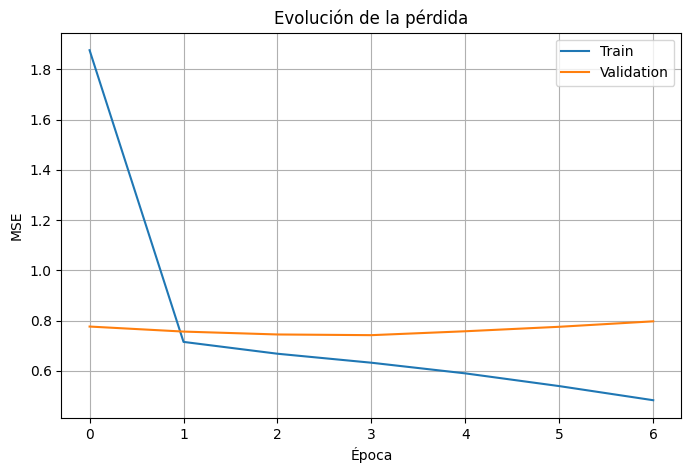

In [39]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Evolución de la pérdida")
plt.legend()
plt.grid(True)

plt.show()

## 5. Mejora del modelo

El entrenamiento inicial muestra una reducción continua del error sobre los datos de entrenamiento. Sin embargo, la pérdida de validación comienza a aumentar después de las primeras épocas, indicando la aparición de sobreajuste.

A partir del modelo inicial se realizan diferentes experimentos con el objetivo de mejorar su capacidad de generalización. Las modificaciones se evaluarán utilizando únicamente el conjunto de validación, manteniendo el conjunto de test reservado para la evaluación final.

### 5.1. Incorporación de Dropout

Como primera estrategia para reducir el sobreajuste se incorpora Dropout entre las principales capas densas.

Durante el entrenamiento, Dropout desactiva aleatoriamente una proporción de las unidades de la red, dificultando que el modelo dependa excesivamente de determinadas conexiones y favoreciendo una mayor capacidad de generalización.

In [40]:
entrada_usuario_2 = keras.Input(shape=(1,), name="usuario")
entrada_pelicula_2 = keras.Input(shape=(1,), name="pelicula")

embedding_usuario_2 = layers.Embedding(
    input_dim=num_usuarios_train,
    output_dim=embedding_dim
)(entrada_usuario_2)

embedding_pelicula_2 = layers.Embedding(
    input_dim=num_peliculas_train,
    output_dim=embedding_dim
)(entrada_pelicula_2)

vector_usuario_2 = layers.Flatten()(embedding_usuario_2)
vector_pelicula_2 = layers.Flatten()(embedding_pelicula_2)

x = layers.Concatenate()([
    vector_usuario_2,
    vector_pelicula_2
])

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

x = layers.Dense(32, activation="relu")(x)

salida_2 = layers.Dense(1, activation="linear")(x)

modelo_dropout = keras.Model(
    inputs=[entrada_usuario_2, entrada_pelicula_2],
    outputs=salida_2
)

modelo_dropout.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

In [41]:
early_stopping_2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_dropout = modelo_dropout.fit(
    x=[X_train_usuario, X_train_pelicula],
    y=y_train,
    validation_data=(
        [X_val_usuario, X_val_pelicula],
        y_val
    ),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping_2],
    verbose=1
)

Epoch 1/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 1.7416 - val_loss: 0.7828
Epoch 2/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7996 - val_loss: 0.7640
Epoch 3/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7367 - val_loss: 0.7547
Epoch 4/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6930 - val_loss: 0.7455
Epoch 5/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6535 - val_loss: 0.7430
Epoch 6/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6144 - val_loss: 0.7536
Epoch 7/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5751 - val_loss: 0.7608
Epoch 8/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5309 - val_loss: 0.7657


El uso de Dropout reduce ligeramente la velocidad con la que el modelo se ajusta a los datos de entrenamiento y retrasa la aparición del sobreajuste. Sin embargo, el mejor valor de pérdida de validación obtenido es similar al del modelo inicial, sin producir una mejora relevante.

Por tanto, se continúa explorando otras configuraciones del modelo.

### 5.2. Reducción de la arquitectura

Dado que el modelo inicial presenta sobreajuste en pocas épocas, se prueba una arquitectura más sencilla con el objetivo de reducir su capacidad y favorecer una mejor generalización.

Se mantienen los embeddings de dimensión 32, pero se reduce el número de capas densas y neuronas.

In [42]:
entrada_usuario_3 = keras.Input(shape=(1,), name="usuario")
entrada_pelicula_3 = keras.Input(shape=(1,), name="pelicula")

embedding_usuario_3 = layers.Embedding(
    input_dim=num_usuarios_train,
    output_dim=embedding_dim
)(entrada_usuario_3)

embedding_pelicula_3 = layers.Embedding(
    input_dim=num_peliculas_train,
    output_dim=embedding_dim
)(entrada_pelicula_3)

vector_usuario_3 = layers.Flatten()(embedding_usuario_3)
vector_pelicula_3 = layers.Flatten()(embedding_pelicula_3)

x = layers.Concatenate()([
    vector_usuario_3,
    vector_pelicula_3
])

x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)

salida_3 = layers.Dense(
    1,
    activation="linear"
)(x)

modelo_reducido = keras.Model(
    inputs=[entrada_usuario_3, entrada_pelicula_3],
    outputs=salida_3
)

modelo_reducido.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

In [43]:
early_stopping_3 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_reducido = modelo_reducido.fit(
    x=[X_train_usuario, X_train_pelicula],
    y=y_train,
    validation_data=(
        [X_val_usuario, X_val_pelicula],
        y_val
    ),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping_3],
    verbose=1
)

Epoch 1/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 2.1235 - val_loss: 0.7769
Epoch 2/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.7213 - val_loss: 0.7682
Epoch 3/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6850 - val_loss: 0.7558
Epoch 4/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6591 - val_loss: 0.7528
Epoch 5/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6325 - val_loss: 0.7381
Epoch 6/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6040 - val_loss: 0.7466
Epoch 7/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5724 - val_loss: 0.7517
Epoch 8/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5376 - val_loss: 0.7764


La reducción de la arquitectura produce una ligera mejora respecto al modelo inicial, alcanzando una pérdida de validación inferior.

El resultado sugiere que aumentar la profundidad y el número de neuronas no aporta una mejora en este conjunto de datos y puede favorecer un ajuste excesivo a las valoraciones de entrenamiento.

Por ello, se toma la arquitectura reducida como nueva referencia para los siguientes experimentos.

### 5.3. Reducción de la dimensión de los embeddings

La mayor parte de los parámetros entrenables del modelo se encuentra en las capas de embeddings.

Con el objetivo de reducir la complejidad del modelo y estudiar si una representación latente más compacta mejora su capacidad de generalización, se reduce la dimensión de los embeddings de 32 a 16 factores.

In [44]:
embedding_dim_16 = 16

entrada_usuario_4 = keras.Input(shape=(1,), name="usuario")
entrada_pelicula_4 = keras.Input(shape=(1,), name="pelicula")

embedding_usuario_4 = layers.Embedding(
    input_dim=num_usuarios_train,
    output_dim=embedding_dim_16
)(entrada_usuario_4)

embedding_pelicula_4 = layers.Embedding(
    input_dim=num_peliculas_train,
    output_dim=embedding_dim_16
)(entrada_pelicula_4)

vector_usuario_4 = layers.Flatten()(embedding_usuario_4)
vector_pelicula_4 = layers.Flatten()(embedding_pelicula_4)

x = layers.Concatenate()([
    vector_usuario_4,
    vector_pelicula_4
])

x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)

salida_4 = layers.Dense(1, activation="linear")(x)

modelo_embedding16 = keras.Model(
    inputs=[entrada_usuario_4, entrada_pelicula_4],
    outputs=salida_4
)

modelo_embedding16.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

In [45]:
early_stopping_4 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_embedding16 = modelo_embedding16.fit(
    x=[X_train_usuario, X_train_pelicula],
    y=y_train,
    validation_data=(
        [X_val_usuario, X_val_pelicula],
        y_val
    ),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping_4],
    verbose=1
)

Epoch 1/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 2.7273 - val_loss: 0.7718
Epoch 2/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7220 - val_loss: 0.7532
Epoch 3/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6832 - val_loss: 0.7516
Epoch 4/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6632 - val_loss: 0.7461
Epoch 5/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6441 - val_loss: 0.7394
Epoch 6/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6283 - val_loss: 0.7385
Epoch 7/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6139 - val_loss: 0.7381
Epoch 8/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6004 - val_loss: 0.7428
Epoch 9/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5875 - val_loss: 0.7414
Epoch 10/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5725 - val_loss: 0.7433


La reducción de la dimensión de los embeddings de 32 a 16 mantiene prácticamente el mismo mejor resultado de validación obtenido con embeddings de dimensión 32.

Dado que la representación de 16 dimensiones requiere un número considerablemente menor de parámetros sin producir una pérdida apreciable de rendimiento, se considera una alternativa más eficiente y se utiliza como referencia para los siguientes experimentos.

### 5.4. Incorporación de sesgos de usuario y película

Además de las preferencias específicas entre usuarios y películas, las valoraciones pueden estar influidas por tendencias generales.

Algunos usuarios tienden a puntuar sistemáticamente más alto o más bajo, mientras que determinadas películas reciben valoraciones generalmente superiores o inferiores.

Para modelar estos efectos se incorporan sesgos aprendibles de usuario y película, representados mediante embeddings de una única dimensión.

In [46]:
entrada_usuario_5 = keras.Input(shape=(1,), name="usuario")
entrada_pelicula_5 = keras.Input(shape=(1,), name="pelicula")

# Embeddings principales
embedding_usuario_5 = layers.Embedding(
    input_dim=num_usuarios_train,
    output_dim=16
)(entrada_usuario_5)

embedding_pelicula_5 = layers.Embedding(
    input_dim=num_peliculas_train,
    output_dim=16
)(entrada_pelicula_5)

vector_usuario_5 = layers.Flatten()(embedding_usuario_5)
vector_pelicula_5 = layers.Flatten()(embedding_pelicula_5)

# Sesgos
bias_usuario = layers.Embedding(
    input_dim=num_usuarios_train,
    output_dim=1
)(entrada_usuario_5)

bias_pelicula = layers.Embedding(
    input_dim=num_peliculas_train,
    output_dim=1
)(entrada_pelicula_5)

bias_usuario = layers.Flatten()(bias_usuario)
bias_pelicula = layers.Flatten()(bias_pelicula)

# Parte neuronal
x = layers.Concatenate()([
    vector_usuario_5,
    vector_pelicula_5
])

x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)

prediccion_base = layers.Dense(
    1,
    activation="linear"
)(x)

# Predicción final con sesgos
salida_5 = layers.Add()([
    prediccion_base,
    bias_usuario,
    bias_pelicula
])

modelo_bias = keras.Model(
    inputs=[entrada_usuario_5, entrada_pelicula_5],
    outputs=salida_5
)

modelo_bias.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

In [47]:
early_stopping_5 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_bias = modelo_bias.fit(
    x=[X_train_usuario, X_train_pelicula],
    y=y_train,
    validation_data=(
        [X_val_usuario, X_val_pelicula],
        y_val
    ),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping_5],
    verbose=1
)

Epoch 1/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 2.5092 - val_loss: 0.7773
Epoch 2/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7220 - val_loss: 0.7613
Epoch 3/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6857 - val_loss: 0.7618
Epoch 4/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6684 - val_loss: 0.7547
Epoch 5/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6526 - val_loss: 0.7553
Epoch 6/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6367 - val_loss: 0.7376
Epoch 7/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6219 - val_loss: 0.7431
Epoch 8/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6064 - val_loss: 0.7459
Epoch 9/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5917 - val_loss: 0.7402


La incorporación de sesgos de usuario y película produce una ligera mejora respecto a las configuraciones anteriores, alcanzando el menor valor de pérdida de validación obtenido hasta el momento.

Sin embargo, las diferencias entre las distintas arquitecturas colaborativas son reducidas. Esto sugiere que continuar aumentando o modificando la arquitectura neuronal sin incorporar nueva información puede ofrecer mejoras limitadas.

Por este motivo, se plantea extender el modelo mediante un enfoque híbrido que incorpore información sobre los géneros de las películas.

## 6. Modelo híbrido con información de contenido

Los modelos desarrollados hasta el momento utilizan exclusivamente información procedente de las interacciones entre usuarios y películas.

Con el objetivo de proporcionar información adicional al modelo, se desarrolla una variante híbrida que combina los embeddings aprendidos de usuarios y películas con los géneros cinematográficos disponibles en `movies.csv`.

De esta forma, la predicción no dependerá únicamente de la identidad del usuario y de la película, sino también de características explícitas asociadas al contenido.

### 6.1. Preparación de los géneros

La columna `genres` contiene uno o varios géneros asociados a cada película, separados mediante el carácter `|`.

Se identifican los diferentes géneros presentes en el dataset para posteriormente transformarlos en una representación numérica que pueda utilizar la red neuronal.

In [48]:
generos = sorted({
    genero
    for lista_generos in movies["genres"]
    for genero in lista_generos.split("|")
})

print("Número de géneros:", len(generos))
print(generos)

Número de géneros: 20
['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


### 6.2. Codificación multi-hot de los géneros

Los géneros se transforman mediante una codificación *multi-hot*, en la que cada género se representa mediante una variable binaria.

A diferencia de una codificación categórica convencional, una película puede presentar simultáneamente varios valores iguales a 1, ya que puede pertenecer a varios géneros.

In [49]:
generos_multi_hot = movies["genres"].str.get_dummies(sep="|")

generos_multi_hot.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [50]:
print(generos_multi_hot.shape)

(9742, 20)


In [51]:
movies_generos = pd.concat(
    [
        movies[["movieId"]],
        generos_multi_hot
    ],
    axis=1
)

movies_generos.head()

,movieId,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,0,0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,5,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 6.3. Incorporación de los géneros a las valoraciones

La información de géneros se incorpora a los conjuntos de entrenamiento y validación mediante el identificador `movieId`.

De esta forma se mantienen las mismas divisiones utilizadas en los modelos anteriores y se añade información de contenido a cada interacción usuario-película.

In [52]:
train_hibrido = train.merge(
    movies_generos,
    on="movieId",
    how="left"
)

validation_hibrido = validation_conocido.merge(
    movies_generos,
    on="movieId",
    how="left"
)

print("Train híbrido:", train_hibrido.shape)
print("Validation híbrido:", validation_hibrido.shape)

display(train_hibrido.head())

Train híbrido: (80668, 26)
Validation híbrido: (9660, 26)


,userId,movieId,rating,timestamp,usuario_idx,pelicula_idx,(no genres listed),Action,Adventure,Animation,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,509,7347,3.0,1435994597,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
1,326,71462,4.0,1322252335,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,57,2115,3.0,965798155,2,2,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,610,1127,4.0,1479544102,3,3,0,1,1,0,...,0,0,0,0,0,0,1,1,0,0
4,462,2409,2.0,1174438249,4,4,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


### 6.4. Preparación de las entradas del modelo híbrido

Además de los índices de usuario y película, el modelo híbrido recibe el vector multi-hot de géneros correspondiente a cada película.

Las valoraciones continúan utilizándose como variable objetivo.

In [53]:
columnas_generos = generos_multi_hot.columns.tolist()

print(columnas_generos)

['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [54]:
X_train_generos = train_hibrido[columnas_generos].to_numpy().astype("float32")
X_val_generos = validation_hibrido[columnas_generos].to_numpy().astype("float32")

print("Géneros train:", X_train_generos.shape)
print("Géneros validation:", X_val_generos.shape)

Géneros train: (80668, 20)
Géneros validation: (9660, 20)


### 6.5. Construcción del modelo híbrido

El modelo híbrido combina tres fuentes de información: el embedding del usuario, el embedding de la película y el vector multi-hot correspondiente a los géneros de la película.

Se mantiene la arquitectura colaborativa que ha obtenido mejores resultados en los experimentos anteriores, incluyendo los sesgos de usuario y película. La información de géneros se concatena con los embeddings antes de ser procesada por las capas densas.

In [55]:
entrada_usuario_h = keras.Input(
    shape=(1,),
    name="usuario"
)

entrada_pelicula_h = keras.Input(
    shape=(1,),
    name="pelicula"
)

entrada_generos_h = keras.Input(
    shape=(len(columnas_generos),),
    name="generos"
)

In [56]:
embedding_usuario_h = layers.Embedding(
    input_dim=num_usuarios_train,
    output_dim=16
)(entrada_usuario_h)

embedding_pelicula_h = layers.Embedding(
    input_dim=num_peliculas_train,
    output_dim=16
)(entrada_pelicula_h)

vector_usuario_h = layers.Flatten()(embedding_usuario_h)
vector_pelicula_h = layers.Flatten()(embedding_pelicula_h)

bias_usuario_h = layers.Embedding(
    input_dim=num_usuarios_train,
    output_dim=1
)(entrada_usuario_h)

bias_pelicula_h = layers.Embedding(
    input_dim=num_peliculas_train,
    output_dim=1
)(entrada_pelicula_h)

bias_usuario_h = layers.Flatten()(bias_usuario_h)
bias_pelicula_h = layers.Flatten()(bias_pelicula_h)

In [57]:
x = layers.Concatenate()([
    vector_usuario_h,
    vector_pelicula_h,
    entrada_generos_h
])

In [58]:
x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)

prediccion_base_h = layers.Dense(
    1,
    activation="linear"
)(x)

salida_h = layers.Add()([
    prediccion_base_h,
    bias_usuario_h,
    bias_pelicula_h
])

In [59]:
modelo_hibrido = keras.Model(
    inputs=[
        entrada_usuario_h,
        entrada_pelicula_h,
        entrada_generos_h
    ],
    outputs=salida_h
)

modelo_hibrido.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

modelo_hibrido.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ usuario             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pelicula            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 1, 16)     │      9,760 │ usuario[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 1, 16)     │    143,728 │ pelicula[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_12          │ (None, 16)        │          0 │ embedding_10[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_13          │ (None, 16)        │          0 │ embedding_11[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generos             │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 52)        │          0 │ flatten_12[0][0], │
│ (Concatenate)       │                   │            │ flatten_13[0][0], │
│                     │                   │            │ generos[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 64)        │      3,392 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 32)        │      2,080 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_12        │ (None, 1, 1)      │        610 │ usuario[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_13        │ (None, 1, 1)      │      8,983 │ pelicula[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 1)         │         33 │ dense_17[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_14          │ (None, 1)         │          0 │ embedding_12[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_15          │ (None, 1)         │          0 │ embedding_13[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1)         │          0 │ dense_18[0][0],   │
│                     │                   │            │ flatten_14[0][0], │
│                     │                   │            │ flatten_15[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 168,586 (658.54 KB)

 Trainable params: 168,586 (658.54 KB)

 Non-trainable params: 0 (0.00 B)

### 6.6. Entrenamiento del modelo híbrido

El modelo híbrido se entrena bajo las mismas condiciones utilizadas en los experimentos anteriores, incorporando como tercera entrada el vector de géneros de cada película.

Se mantiene el uso de `EarlyStopping` para conservar los pesos correspondientes al menor error de validación y reducir el riesgo de sobreajuste.

In [60]:
early_stopping_h = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_hibrido = modelo_hibrido.fit(
    x=[
        X_train_usuario,
        X_train_pelicula,
        X_train_generos
    ],
    y=y_train,
    validation_data=(
        [
            X_val_usuario,
            X_val_pelicula,
            X_val_generos
        ],
        y_val
    ),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping_h],
    verbose=1
)

Epoch 1/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.8469 - val_loss: 0.7791
Epoch 2/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7212 - val_loss: 0.7570
Epoch 3/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6778 - val_loss: 0.7466
Epoch 4/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6522 - val_loss: 0.7497
Epoch 5/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6333 - val_loss: 0.7414
Epoch 6/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6164 - val_loss: 0.7326
Epoch 7/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6010 - val_loss: 0.7307
Epoch 8/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5871 - val_loss: 0.7298
Epoch 9/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5727 - val_loss: 0.7321
Epoch 10/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5567 - val_loss: 0.7251
Epoch 11/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5419 - val_loss: 0.7319
Epoch 12/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

### 6.7. Resultado del modelo híbrido

La incorporación de los géneros de las películas permite reducir la pérdida de validación respecto a las variantes basadas exclusivamente en información colaborativa.

El modelo híbrido alcanza un `val_loss` mínimo de 0.7251, frente al valor de 0.7376 obtenido por la mejor configuración colaborativa anterior.

Aunque la mejora no es muy elevada, el resultado muestra que la incorporación de información de contenido aporta información útil para la predicción de las valoraciones.

## 7. Modelo híbrido con preferencias de género

Como extensión del modelo híbrido anterior, se incorpora información sobre las preferencias históricas de cada usuario.

A partir exclusivamente del conjunto de entrenamiento se calcula un perfil de usuario que representa su valoración media para cada género cinematográfico. De esta forma, el modelo dispone tanto de información sobre los géneros de la película como de las preferencias del usuario respecto a dichos géneros.

El cálculo se realiza únicamente con datos de entrenamiento para evitar la utilización de información procedente de validación o test.

In [61]:
preferencias_usuario = {}

for genero in columnas_generos:

    suma_ratings = (
        train_hibrido["rating"] * train_hibrido[genero]
    ).groupby(train_hibrido["userId"]).sum()

    numero_ratings = (
        train_hibrido[genero]
    ).groupby(train_hibrido["userId"]).sum()

    preferencias_usuario[genero] = (
        suma_ratings / numero_ratings
    )

In [62]:
preferencias_usuario = pd.DataFrame(preferencias_usuario)

preferencias_usuario.head()

,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,,
1,NaN,4.283784,4.352113,4.611111,4.468750,4.275362,4.282051,NaN,4.483333,4.222222,NaN,3.357143,NaN,4.5625,4.133333,4.318182,4.285714,4.142857,4.526316,4.166667
2,NaN,4.000000,4.166667,NaN,NaN,4.000000,3.777778,4.333333,3.807692,NaN,NaN,3.000000,3.75,NaN,4.000000,4.500000,3.875000,3.666667,4.500000,NaN
3,NaN,3.375000,3.000000,0.500000,0.500000,1.250000,0.500000,NaN,0.807692,3.375000,NaN,4.687500,NaN,NaN,5.000000,0.500000,4.230769,4.000000,0.500000,NaN
4,NaN,3.210526,3.692308,4.000000,3.800000,3.425287,3.647059,4.000000,3.340659,3.764706,4.0,4.333333,3.00,4.0000,3.222222,3.255319,2.700000,3.357143,3.500000,3.500000
5,NaN,3.125000,3.200000,4.400000,4.142857,3.461538,4.000000,NaN,3.857143,4.166667,NaN,3.000000,4.00,4.4000,4.000000,3.090909,2.500000,3.555556,3.333333,3.000000


In [63]:
media_usuario = train.groupby("userId")["rating"].mean()

In [64]:
for usuario in preferencias_usuario.index:
    preferencias_usuario.loc[usuario] = (
        preferencias_usuario.loc[usuario]
        .fillna(media_usuario.loc[usuario])
    )

In [65]:
print(
    "Valores NaN:",
    preferencias_usuario.isna().sum().sum()
)

display(preferencias_usuario.head())

Valores NaN: 0


,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
userId,,,,,,,,,,,,,,,,,,,,
1,4.331606,4.283784,4.352113,4.611111,4.468750,4.275362,4.282051,4.331606,4.483333,4.222222,4.331606,3.357143,4.331606,4.562500,4.133333,4.318182,4.285714,4.142857,4.526316,4.166667
2,3.920000,4.000000,4.166667,3.920000,3.920000,4.000000,3.777778,4.333333,3.807692,3.920000,3.920000,3.000000,3.750000,3.920000,4.000000,4.500000,3.875000,3.666667,4.500000,3.920000
3,2.580645,3.375000,3.000000,0.500000,0.500000,1.250000,0.500000,2.580645,0.807692,3.375000,2.580645,4.687500,2.580645,2.580645,5.000000,0.500000,4.230769,4.000000,0.500000,2.580645
4,3.464706,3.210526,3.692308,4.000000,3.800000,3.425287,3.647059,4.000000,3.340659,3.764706,4.000000,4.333333,3.000000,4.000000,3.222222,3.255319,2.700000,3.357143,3.500000,3.500000
5,3.657895,3.125000,3.200000,4.400000,4.142857,3.461538,4.000000,3.657895,3.857143,4.166667,3.657895,3.000000,4.000000,4.400000,4.000000,3.090909,2.500000,3.555556,3.333333,3.000000


### 7.2. Incorporación de las preferencias a los conjuntos de datos

El perfil de preferencias calculado para cada usuario se incorpora a las interacciones de entrenamiento y validación.

Cada valoración queda así asociada tanto a las características de género de la película como al perfil histórico del usuario que realiza la valoración.

In [66]:
preferencias_usuario = preferencias_usuario.add_prefix("pref_")

preferencias_usuario.head()

,pref_(no genres listed),pref_Action,pref_Adventure,pref_Animation,pref_Children,pref_Comedy,pref_Crime,pref_Documentary,pref_Drama,pref_Fantasy,pref_Film-Noir,pref_Horror,pref_IMAX,pref_Musical,pref_Mystery,pref_Romance,pref_Sci-Fi,pref_Thriller,pref_War,pref_Western
userId,,,,,,,,,,,,,,,,,,,,
1,4.331606,4.283784,4.352113,4.611111,4.468750,4.275362,4.282051,4.331606,4.483333,4.222222,4.331606,3.357143,4.331606,4.562500,4.133333,4.318182,4.285714,4.142857,4.526316,4.166667
2,3.920000,4.000000,4.166667,3.920000,3.920000,4.000000,3.777778,4.333333,3.807692,3.920000,3.920000,3.000000,3.750000,3.920000,4.000000,4.500000,3.875000,3.666667,4.500000,3.920000
3,2.580645,3.375000,3.000000,0.500000,0.500000,1.250000,0.500000,2.580645,0.807692,3.375000,2.580645,4.687500,2.580645,2.580645,5.000000,0.500000,4.230769,4.000000,0.500000,2.580645
4,3.464706,3.210526,3.692308,4.000000,3.800000,3.425287,3.647059,4.000000,3.340659,3.764706,4.000000,4.333333,3.000000,4.000000,3.222222,3.255319,2.700000,3.357143,3.500000,3.500000
5,3.657895,3.125000,3.200000,4.400000,4.142857,3.461538,4.000000,3.657895,3.857143,4.166667,3.657895,3.000000,4.000000,4.400000,4.000000,3.090909,2.500000,3.555556,3.333333,3.000000


In [67]:
preferencias_usuario = preferencias_usuario.reset_index()

In [68]:
train_hibrido_pref = train_hibrido.merge(
    preferencias_usuario,
    on="userId",
    how="left"
)

validation_hibrido_pref = validation_hibrido.merge(
    preferencias_usuario,
    on="userId",
    how="left"
)

print("Train:", train_hibrido_pref.shape)
print("Validation:", validation_hibrido_pref.shape)

Train: (80668, 46)
Validation: (9660, 46)


In [69]:
columnas_preferencias = [
    f"pref_{genero}"
    for genero in columnas_generos
]

print(columnas_preferencias)

['pref_(no genres listed)', 'pref_Action', 'pref_Adventure', 'pref_Animation', 'pref_Children', 'pref_Comedy', 'pref_Crime', 'pref_Documentary', 'pref_Drama', 'pref_Fantasy', 'pref_Film-Noir', 'pref_Horror', 'pref_IMAX', 'pref_Musical', 'pref_Mystery', 'pref_Romance', 'pref_Sci-Fi', 'pref_Thriller', 'pref_War', 'pref_Western']


In [70]:
X_train_preferencias = (
    train_hibrido_pref[columnas_preferencias]
    .to_numpy()
    .astype("float32")
)

X_val_preferencias = (
    validation_hibrido_pref[columnas_preferencias]
    .to_numpy()
    .astype("float32")
)

print(
    "Preferencias train:",
    X_train_preferencias.shape
)

print(
    "Preferencias validation:",
    X_val_preferencias.shape
)

Preferencias train: (80668, 20)
Preferencias validation: (9660, 20)


In [71]:
print("NaN train:", np.isnan(X_train_preferencias).sum())
print("NaN validation:", np.isnan(X_val_preferencias).sum())

NaN train: 0
NaN validation: 0


### 7.3. Construcción del modelo híbrido con preferencias de usuario

El nuevo modelo amplía la arquitectura híbrida anterior incorporando el perfil de preferencias de género de cada usuario.

La red recibe cuatro fuentes de información: el identificador del usuario, el identificador de la película, los géneros de la película y las preferencias históricas del usuario por cada género.

Esta combinación permite proporcionar al modelo información explícita tanto sobre las características de la película como sobre los gustos derivados del historial del usuario.

In [72]:
entrada_usuario_p = keras.Input(
    shape=(1,),
    name="usuario"
)

entrada_pelicula_p = keras.Input(
    shape=(1,),
    name="pelicula"
)

entrada_generos_p = keras.Input(
    shape=(len(columnas_generos),),
    name="generos"
)

entrada_preferencias_p = keras.Input(
    shape=(len(columnas_preferencias),),
    name="preferencias"
)

In [73]:
embedding_usuario_p = layers.Embedding(
    input_dim=num_usuarios_train,
    output_dim=16
)(entrada_usuario_p)

embedding_pelicula_p = layers.Embedding(
    input_dim=num_peliculas_train,
    output_dim=16
)(entrada_pelicula_p)

vector_usuario_p = layers.Flatten()(embedding_usuario_p)
vector_pelicula_p = layers.Flatten()(embedding_pelicula_p)

bias_usuario_p = layers.Embedding(
    input_dim=num_usuarios_train,
    output_dim=1
)(entrada_usuario_p)

bias_pelicula_p = layers.Embedding(
    input_dim=num_peliculas_train,
    output_dim=1
)(entrada_pelicula_p)

bias_usuario_p = layers.Flatten()(bias_usuario_p)
bias_pelicula_p = layers.Flatten()(bias_pelicula_p)

In [74]:
x = layers.Concatenate()([
    vector_usuario_p,
    vector_pelicula_p,
    entrada_generos_p,
    entrada_preferencias_p
])

In [75]:
x = layers.Dense(64, activation="relu")(x)
x = layers.Dense(32, activation="relu")(x)

prediccion_base_p = layers.Dense(
    1,
    activation="linear"
)(x)

salida_p = layers.Add()([
    prediccion_base_p,
    bias_usuario_p,
    bias_pelicula_p
])

In [76]:
modelo_hibrido_pref = keras.Model(
    inputs=[
        entrada_usuario_p,
        entrada_pelicula_p,
        entrada_generos_p,
        entrada_preferencias_p
    ],
    outputs=salida_p
)

modelo_hibrido_pref.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

modelo_hibrido_pref.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ usuario             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pelicula            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_14        │ (None, 1, 16)     │      9,760 │ usuario[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_15        │ (None, 1, 16)     │    143,728 │ pelicula[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_16          │ (None, 16)        │          0 │ embedding_14[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_17          │ (None, 16)        │          0 │ embedding_15[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generos             │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preferencias        │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 72)        │          0 │ flatten_16[0][0], │
│ (Concatenate)       │                   │            │ flatten_17[0][0], │
│                     │                   │            │ generos[0][0],    │
│                     │                   │            │ preferencias[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 64)        │      4,672 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 32)        │      2,080 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_16        │ (None, 1, 1)      │        610 │ usuario[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_17        │ (None, 1, 1)      │      8,983 │ pelicula[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 1)         │         33 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_18          │ (None, 1)         │          0 │ embedding_16[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_19          │ (None, 1)         │          0 │ embedding_17[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1)         │          0 │ dense_21[0][0],   │
│                     │                   │            │ flatten_18[0][0]

 Total params: 169,866 (663.54 KB)

 Trainable params: 169,866 (663.54 KB)

 Non-trainable params: 0 (0.00 B)

### 7.4. Entrenamiento del modelo

El modelo se entrena bajo las mismas condiciones que las arquitecturas anteriores para permitir una comparación consistente de los resultados obtenidos en validación.

Se utiliza nuevamente `EarlyStopping`, conservando los pesos correspondientes a la época con menor pérdida de validación.

In [77]:
early_stopping_p = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_hibrido_pref = modelo_hibrido_pref.fit(
    x=[
        X_train_usuario,
        X_train_pelicula,
        X_train_generos,
        X_train_preferencias
    ],
    y=y_train,
    validation_data=(
        [
            X_val_usuario,
            X_val_pelicula,
            X_val_generos,
            X_val_preferencias
        ],
        y_val
    ),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping_p],
    verbose=1
)

Epoch 1/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 1.0968 - val_loss: 0.7706
Epoch 2/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7115 - val_loss: 0.7433
Epoch 3/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6671 - val_loss: 0.7387
Epoch 4/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6392 - val_loss: 0.7419
Epoch 5/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6205 - val_loss: 0.7259
Epoch 6/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6046 - val_loss: 0.7286
Epoch 7/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5918 - val_loss: 0.7316
Epoch 8/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5828 - val_loss: 0.7243
Epoch 9/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5730 - val_loss: 0.7293
Epoch 10/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5604 - val_loss: 0.7212
Epoch 11/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5490 - val_loss: 0.7249
Epoch 12/50
316/316 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

### 7.5. Resultado del modelo híbrido con preferencias

La incorporación del perfil de preferencias de género de los usuarios produce el mejor resultado de validación de las arquitecturas desarrolladas.

El modelo alcanza un `val_loss` mínimo de 0.7212, mejorando el resultado de 0.7251 obtenido por el modelo híbrido basado únicamente en los géneros de las películas.

Los resultados indican que la incorporación de información de contenido resulta más beneficiosa que el aumento de la complejidad de la arquitectura neuronal. Además, la utilización del historial de entrenamiento para representar las preferencias de género de los usuarios proporciona información adicional útil para la predicción.

## 8. Selección y guardado del modelo final

Tras comparar las diferentes configuraciones mediante el conjunto de validación, se selecciona como modelo final la arquitectura híbrida que combina embeddings de usuarios y películas, sesgos, géneros cinematográficos y perfiles de preferencias de género de los usuarios.

Este modelo obtiene el menor valor de pérdida de validación de los experimentos realizados.

El modelo y los elementos necesarios para reproducir el preprocesamiento se almacenan para su posterior evaluación sobre el conjunto de test y su futura integración en la aplicación.

In [78]:
resultados_validacion = pd.DataFrame({
    "Modelo": [
        "Base",
        "Dropout",
        "Red reducida",
        "Embedding 16",
        "Embedding 16 + sesgos",
        "Híbrido con géneros",
        "Híbrido con preferencias"
    ],
    "Mejor val_loss": [
        min(history.history["val_loss"]),
        min(history_dropout.history["val_loss"]),
        min(history_reducido.history["val_loss"]),
        min(history_embedding16.history["val_loss"]),
        min(history_bias.history["val_loss"]),
        min(history_hibrido.history["val_loss"]),
        min(history_hibrido_pref.history["val_loss"])
    ]
})

resultados_validacion = resultados_validacion.sort_values(
    "Mejor val_loss"
).reset_index(drop=True)

resultados_validacion

,Modelo,Mejor val_loss
0,Híbrido con preferencias,0.721168
1,Híbrido con géneros,0.725077
2,Embedding 16 + sesgos,0.737635
3,Embedding 16,0.738068
4,Red reducida,0.738092
5,Base,0.741663
6,Dropout,0.742973


In [79]:
import os

ruta_modelos = "/content/drive/MyDrive/TFM/modelos"

os.makedirs(
    ruta_modelos,
    exist_ok=True
)

In [80]:
modelo_hibrido_pref.save(
    f"{ruta_modelos}/modelo_deep_learning.keras"
)

In [81]:
restore_best_weights=True

In [83]:
with open(
    f"{ruta_modelos}/usuario_a_indice.pkl",
    "wb"
) as f:
    pickle.dump(usuario_a_indice, f)

with open(
    f"{ruta_modelos}/pelicula_a_indice.pkl",
    "wb"
) as f:
    pickle.dump(pelicula_a_indice, f)

In [84]:
with open(
    f"{ruta_modelos}/columnas_generos.pkl",
    "wb"
) as f:
    pickle.dump(columnas_generos, f)

In [85]:
preferencias_usuario.to_csv(
    f"{ruta_modelos}/preferencias_usuario.csv",
    index=False
)

In [86]:
resultados_validacion.to_csv(
    f"{ruta_modelos}/resultados_validacion.csv",
    index=False
)

In [87]:
train.to_csv(
    f"{ruta_modelos}/train.csv",
    index=False
)

validation.to_csv(
    f"{ruta_modelos}/validation.csv",
    index=False
)

test.to_csv(
    f"{ruta_modelos}/test.csv",
    index=False
)

## 9. Conclusiones

Durante el desarrollo se han probado diferentes arquitecturas de Deep Learning para la predicción de valoraciones de películas.

El modelo inicial, basado en embeddings de usuarios y películas y varias capas densas, mostró una rápida aparición de sobreajuste. A partir de este modelo se probaron diferentes estrategias, incluyendo Dropout, reducción de la arquitectura, modificación de la dimensión de los embeddings e incorporación de sesgos de usuario y película.

Las modificaciones realizadas sobre la arquitectura puramente colaborativa produjeron mejoras reducidas. En cambio, la incorporación de información adicional sobre los géneros de las películas permitió reducir de forma más apreciable el error de validación.

Finalmente, se incorporó un perfil de preferencias de género calculado a partir del historial de entrenamiento de cada usuario. Esta configuración obtuvo el mejor resultado de validación, con un `val_loss` de 0.7212, y fue seleccionada como modelo final.

El modelo seleccionado y los elementos necesarios para reproducir su preprocesamiento han sido almacenados para realizar posteriormente su evaluación sobre el conjunto de test y facilitar su integración en la aplicación.